<a href="https://colab.research.google.com/github/ejr-00/lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


In [19]:
import pandas as pd
import torch

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from torch.utils.data import TensorDataset, DataLoader

In [27]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cpu


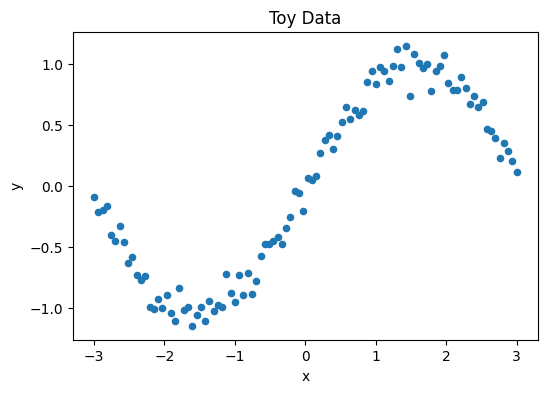

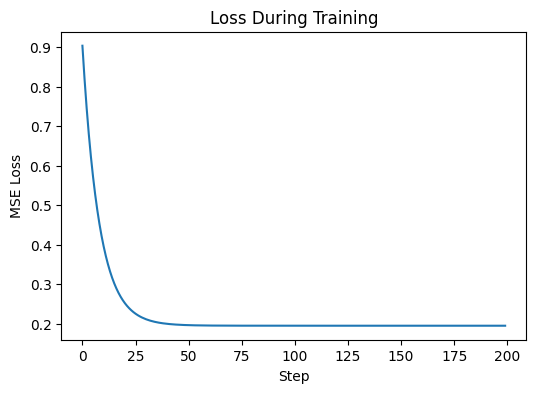

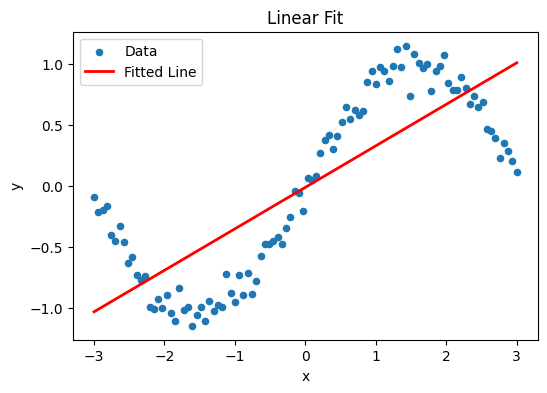

In [2]:
# Generate the toy data
np.random.seed(42)

x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

# Plot the data
plt.figure(figsize=(6,4))
plt.scatter(x, y, s=20)
plt.title("Toy Data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Initialise w and b
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

lr = 0.01
losses = []

# Gradient Descent
for step in range(200):

    # Predictions
    y_hat = w * x + b

    # Loss
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Update parameters
    w -= lr * dw
    b -= lr * db

# Plot the loss curve
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss During Training")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

# Plot fitted line
plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data", s=20)
plt.plot(x, w * x + b, color="red", linewidth=2, label="Fitted Line")
plt.title("Linear Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

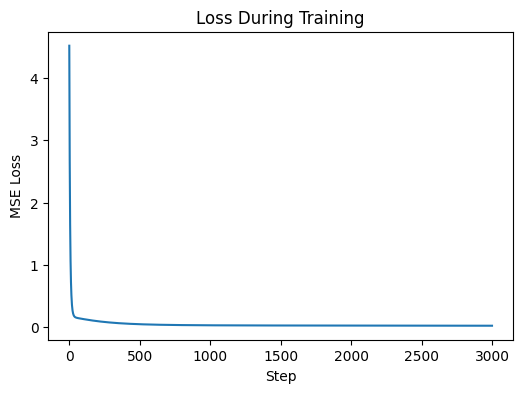

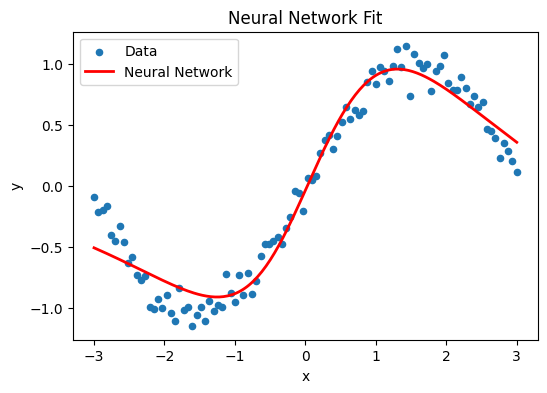

In [5]:
# Reshape the data
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

# Initialise parameters
np.random.seed(42)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5

W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

lr = 0.01
losses = []

# Training
for step in range(3000):

    # Forward pass
    z1 = x @ W1 + b1
    h = np.tanh(z1)

    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update parameters
    W2 -= lr * dW2
    b2 -= lr * db2

    W1 -= lr * dW1
    b1 -= lr * db1

# Plot loss
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss During Training")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

# Plot final fit
plt.figure(figsize=(6,4))
plt.scatter(x, y, s=20, label="Data")

x_plot = np.linspace(-3, 3, 200).reshape(-1,1)
z1 = x_plot @ W1 + b1
h = np.tanh(z1)
y_plot = h @ W2 + b2

plt.plot(x_plot, y_plot, color="red", linewidth=2, label="Neural Network")
plt.title("Neural Network Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

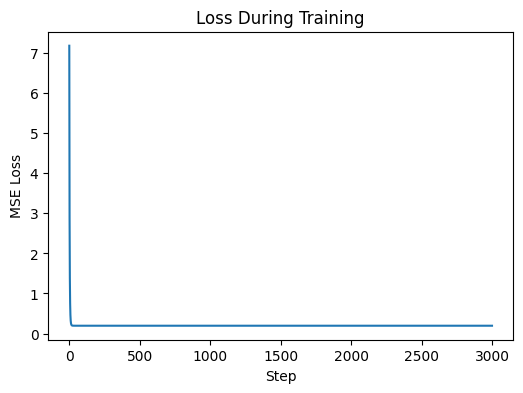

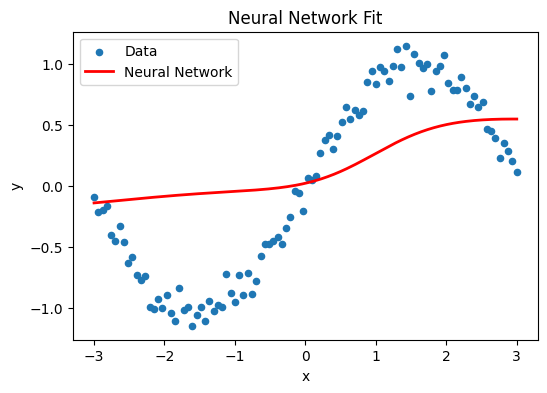

In [6]:
# Reshape the data
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

# Initialise parameters
np.random.seed(42)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5

W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

lr = 0.01
losses = []

# Training
for step in range(3000):

    # Forward pass
    z1 = x @ W1 + b1
    h = z1

    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T
    dz1 = dh

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update parameters
    W2 -= lr * dW2
    b2 -= lr * db2

    W1 -= lr * dW1
    b1 -= lr * db1

# Plot loss
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss During Training")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

# Plot final fit
plt.figure(figsize=(6,4))
plt.scatter(x, y, s=20, label="Data")

x_plot = np.linspace(-3, 3, 200).reshape(-1,1)
z1 = x_plot @ W1 + b1
h = np.tanh(z1)
y_plot = h @ W2 + b2

plt.plot(x_plot, y_plot, color="red", linewidth=2, label="Neural Network")
plt.title("Neural Network Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [15]:
def train_toy(lr, steps=3000):

    # Reset seed so every run starts with the same weights
    np.random.seed(42)

    # Initialise parameters
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5

    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    losses = []

    for step in range(steps):

        # Forward pass
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2

        loss = np.mean((y_hat - y) ** 2)
        losses.append(loss)

        # Backward pass
        d_yhat = 2 * (y_hat - y) / len(y)

        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)

        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)

        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        # Update
        W2 -= lr * dW2
        b2 -= lr * db2

        W1 -= lr * dW1
        b1 -= lr * db1

    return losses

In [16]:
print(loss_1[-1])
print(loss_2[-1])
print(loss_3[-1])

0.07181850562493927
0.010998766930595295
nan


In [17]:
print(max(loss_1))
print(max(loss_2))
print(max(loss_3))

4.516008946623703
4.516008946623703
inf


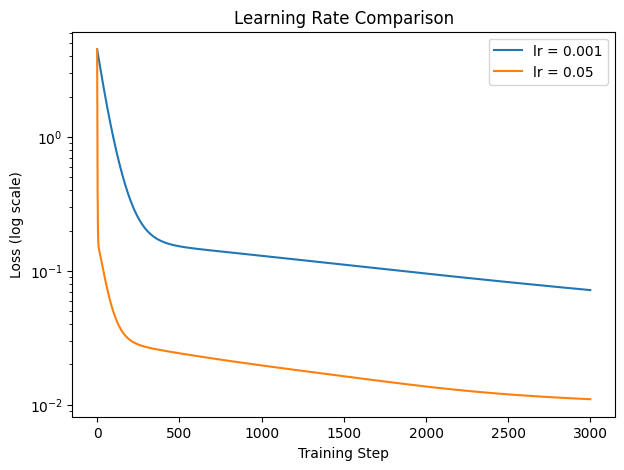

In [18]:
plt.figure(figsize=(7,5))

plt.plot(loss_1, label="lr = 0.001")
plt.plot(loss_2, label="lr = 0.05")

if np.isfinite(loss_3).all():
    plt.plot(loss_3, label="lr = 1.0")

plt.yscale("log")
plt.xlabel("Training Step")
plt.ylabel("Loss (log scale)")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

In [26]:
# Load dataset
obesity = pd.read_csv("Obesity_level_prediction_dataset (2) (1).csv")

# Binary encoding
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    obesity[col] = obesity[col].map({"yes": 1, "no": 0})

# Gender
obesity["Gender"] = obesity["Gender"].map({"Female": 0, "Male": 1})

# Ordinal encoding
obesity["CAEC"] = obesity["CAEC"].map({
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3
})

obesity["CALC"] = obesity["CALC"].map({
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3
})

# Transport
obesity["MTRANS"] = LabelEncoder().fit_transform(obesity["MTRANS"])

# Encode target
target_encoder = LabelEncoder()
obesity["NObeyesdad"] = target_encoder.fit_transform(obesity["NObeyesdad"])

# Features and target
X = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

# Train / Validation / Test split (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# Standardize
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.long)
y_val = torch.tensor(y_val.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

# DataLoaders
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [28]:
import torch
import torch.nn as nn

# Feedforward Neural Network
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_sizes[0]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[1], n_classes)
        )

    def forward(self, x):
        return self.network(x)


# Instantiate model
input_dim = X_train.shape[1]

model = FeedForwardNet(input_dim=input_dim)
model = model.to(DEVICE)

print(model)


# Count trainable parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", num_params)

# Verify first layer by hand
first_layer_params = input_dim * 64 + 64
print("First layer parameters:", first_layer_params)

FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Trainable parameters: 3399
First layer parameters: 1088


Epoch  1/50 | Train Loss: 1.7312 | Val Loss: 1.7234 | Train Acc: 0.4937 | Val Acc: 0.4905
Epoch  2/50 | Train Loss: 1.3842 | Val Loss: 1.3978 | Train Acc: 0.5821 | Val Acc: 0.5758
Epoch  3/50 | Train Loss: 1.0232 | Val Loss: 1.0606 | Train Acc: 0.6572 | Val Acc: 0.6351
Epoch  4/50 | Train Loss: 0.8315 | Val Loss: 0.8838 | Train Acc: 0.7109 | Val Acc: 0.6706
Epoch  5/50 | Train Loss: 0.6986 | Val Loss: 0.7695 | Train Acc: 0.7844 | Val Acc: 0.7630
Epoch  6/50 | Train Loss: 0.6035 | Val Loss: 0.6832 | Train Acc: 0.8144 | Val Acc: 0.7938
Epoch  7/50 | Train Loss: 0.5251 | Val Loss: 0.6153 | Train Acc: 0.8389 | Val Acc: 0.8104
Epoch  8/50 | Train Loss: 0.4577 | Val Loss: 0.5551 | Train Acc: 0.8578 | Val Acc: 0.8270
Epoch  9/50 | Train Loss: 0.4085 | Val Loss: 0.5142 | Train Acc: 0.8712 | Val Acc: 0.8365
Epoch 10/50 | Train Loss: 0.3688 | Val Loss: 0.4760 | Train Acc: 0.8831 | Val Acc: 0.8341
Epoch 11/50 | Train Loss: 0.3280 | Val Loss: 0.4455 | Train Acc: 0.9036 | Val Acc: 0.8602
Epoch 12/5

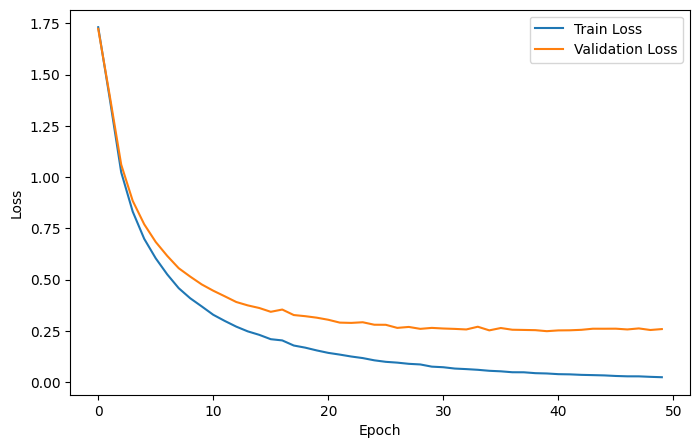

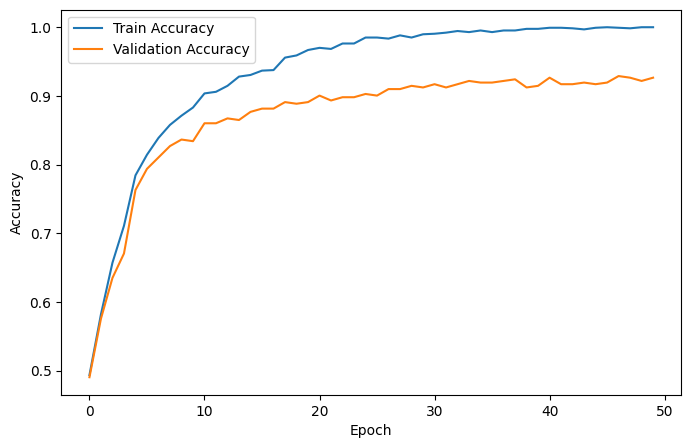

In [29]:
import matplotlib.pyplot as plt

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# History
train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_val_acc = 0

epochs = 50

for epoch in range(epochs):

    # -------------------
    # Training
    # -------------------
    model.train()

    for xb, yb in train_loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

    # -------------------
    # Evaluation
    # -------------------
    model.eval()

    train_loss = 0
    val_loss = 0

    train_correct = 0
    val_correct = 0

    train_total = 0
    val_total = 0

    with torch.no_grad():

        # Training metrics
        for xb, yb in train_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)

            train_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            train_correct += (preds == yb).sum().item()
            train_total += yb.size(0)

        # Validation metrics
        for xb, yb in val_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

    print(
        f"Epoch {epoch+1:2d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

# -------------------
# Loss Curve
# -------------------
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -------------------
# Accuracy Curve
# -------------------
plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [30]:
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64,32), n_classes=7, dropout=0.0):
        super().__init__()

        layers = []
        in_features = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            in_features = h

        layers.append(nn.Linear(in_features, n_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [31]:
def run_experiment(hidden_sizes=(64,32),
                   lr=1e-3,
                   batch_size=32,
                   epochs=50,
                   dropout=0.0):

    train_loader = DataLoader(train_dataset,
                              batch_size=batch_size,
                              shuffle=True)

    val_loader = DataLoader(val_dataset,
                            batch_size=batch_size,
                            shuffle=False)

    model = FeedForwardNet(
        input_dim=X_train.shape[1],
        hidden_sizes=hidden_sizes,
        dropout=dropout
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        model.train()

        for xb, yb in train_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            loss = criterion(model(xb), yb)

            loss.backward()

            optimizer.step()

        model.eval()

        train_loss = 0
        val_loss = 0

        train_correct = 0
        val_correct = 0

        train_total = 0
        val_total = 0

        with torch.no_grad():

            for xb, yb in train_loader:

                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)

                train_loss += criterion(logits, yb).item()

                preds = logits.argmax(1)

                train_correct += (preds == yb).sum().item()

                train_total += len(yb)

            for xb, yb in val_loader:

                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)

                val_loss += criterion(logits, yb).item()

                preds = logits.argmax(1)

                val_correct += (preds == yb).sum().item()

                val_total += len(yb)

        history["train_loss"].append(train_loss/len(train_loader))
        history["val_loss"].append(val_loss/len(val_loader))

        history["train_acc"].append(train_correct/train_total)
        history["val_acc"].append(val_correct/val_total)

    return history

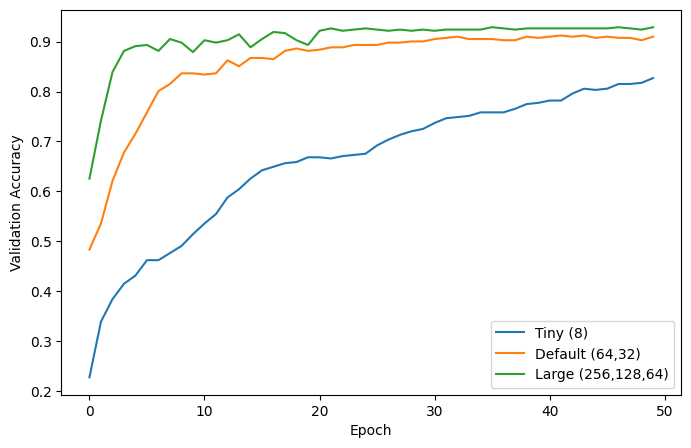

In [32]:
tiny = run_experiment(hidden_sizes=(8,))
default = run_experiment(hidden_sizes=(64,32))
large = run_experiment(hidden_sizes=(256,128,64))

plt.figure(figsize=(8,5))

plt.plot(tiny["val_acc"], label="Tiny (8)")
plt.plot(default["val_acc"], label="Default (64,32)")
plt.plot(large["val_acc"], label="Large (256,128,64)")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

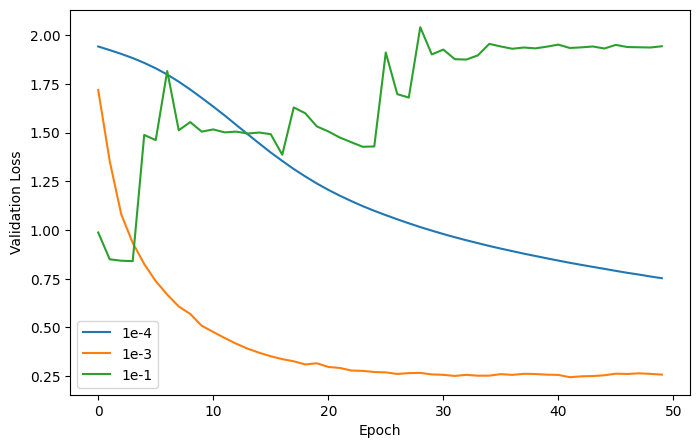

In [33]:
lr1 = run_experiment(lr=1e-4)
lr2 = run_experiment(lr=1e-3)
lr3 = run_experiment(lr=1e-1)

plt.figure(figsize=(8,5))

plt.plot(lr1["val_loss"], label="1e-4")
plt.plot(lr2["val_loss"], label="1e-3")
plt.plot(lr3["val_loss"], label="1e-1")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()

plt.show()

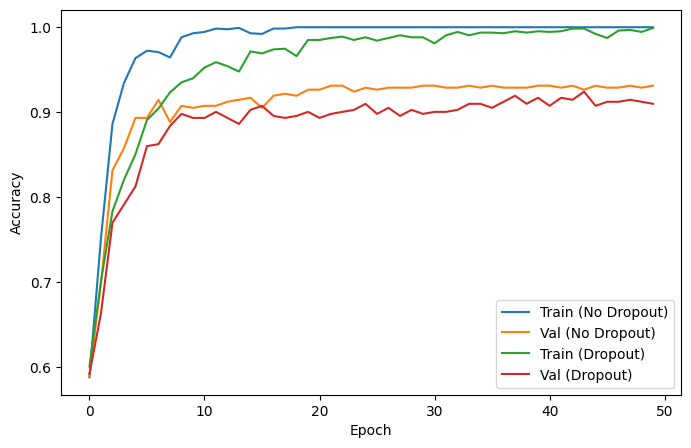

In [34]:
no_dropout = run_experiment(
    hidden_sizes=(256,128,64),
    dropout=0.0
)

dropout = run_experiment(
    hidden_sizes=(256,128,64),
    dropout=0.3
)

plt.figure(figsize=(8,5))

plt.plot(no_dropout["train_acc"], label="Train (No Dropout)")
plt.plot(no_dropout["val_acc"], label="Val (No Dropout)")

plt.plot(dropout["train_acc"], label="Train (Dropout)")
plt.plot(dropout["val_acc"], label="Val (Dropout)")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()